# Лабораторная работа №3
Егорова Варвара Александровна, P3323, 408575

## Классификация новостей [AG's News Topic Classification Dataset](https://github.com/mhjabreel/CharCnn_Keras/tree/master/data/ag_news_csv)

Используется три архитектуры нейронных сетей:
- Одномерная сверточная нейросеть
- Рекуррентная нейросеть LSTM
- Рекуррентная нейросеть GRU

Для ускорения обучения сети рекомендуется подключить GPU (Runtime -> Change Runtime Type -> Hardware Accelerator -> GPU).

## Загрузка и просмотр датасета

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras import utils
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import utils
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
# Максимальное количество уникальных слов слов
num_words = 10000
# Максимальная длина новости
max_news_len = 30
# Количество классов новостей
nb_classes = 4

### Загрузка набора данных

Загружаем данные для обучения

In [ ]:
!wget https://github.com/mhjabreel/CharCnn_Keras/raw/master/data/ag_news_csv/train.csv -O train.csv

--2026-01-11 23:23:59--  https://github.com/mhjabreel/CharCnn_Keras/raw/master/data/ag_news_csv/train.csv
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv [following]
--2026-01-11 23:24:00--  https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29470338 (28M) [text/plain]
Saving to: ‘train.csv’

train.csv           100%[===================>]  28.10M   184MB/s    in 0.2s    

2026-01-11 23:24:01 (184 MB/s) - ‘train.csv’ saved [29470338/29470338]



Загружаем данные для тестирования

In [ ]:
!wget https://github.com/mhjabreel/CharCnn_Keras/raw/master/data/ag_news_csv/test.csv -O test.csv

--2026-01-11 23:24:01--  https://github.com/mhjabreel/CharCnn_Keras/raw/master/data/ag_news_csv/test.csv
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv [following]
--2026-01-11 23:24:01--  https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1857427 (1.8M) [text/plain]
Saving to: ‘test.csv’

test.csv            100%[===================>]   1.77M  --.-KB/s    in 0.04s   

2026-01-11 23:24:02 (43.2 MB/s) - ‘test.csv’ saved [1857427/1857427]



Загружаем имена классов

In [ ]:
!wget https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/classes.txt -O classes.txt

--2026-01-11 23:24:02--  https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/classes.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31 [text/plain]
Saving to: ‘classes.txt’

classes.txt         100%[===================>]      31  --.-KB/s    in 0s      

2026-01-11 23:24:02 (686 KB/s) - ‘classes.txt’ saved [31/31]



### Просматриваем данные

In [ ]:
!ls

classes.txt  sample_data  test.csv  train.csv


In [ ]:
!cat classes.txt

World
Sports
Business
Sci/Tech


In [ ]:
!head train.csv

"3","Wall St. Bears Claw Back Into the Black (Reuters)","Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again."
"3","Carlyle Looks Toward Commercial Aerospace (Reuters)","Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market."
"3","Oil and Economy Cloud Stocks' Outlook (Reuters)","Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums."
"3","Iraq Halts Oil Exports from Main Southern Pipeline (Reuters)","Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed a rebel militia could strike\infrastructure, an oil official said on Saturday."
"3","Oil prices soar to all-time record, posing new menace to US e

In [ ]:
!head test.csv

"3","Fears for T N pension after talks","Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul."
"4","The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com)","SPACE.com - TORONTO, Canada -- A second\team of rocketeers competing for the  #36;10 million Ansari X Prize, a contest for\privately funded suborbital space flight, has officially announced the first\launch date for its manned rocket."
"4","Ky. Company Wins Grant to Study Peptides (AP)","AP - A company founded by a chemistry researcher at the University of Louisville won a grant to develop a method of producing better peptides, which are short chains of amino acids, the building blocks of proteins."
"4","Prediction Unit Helps Forecast Wildfires (AP)","AP - It's barely dawn when Mike Fitzpatrick starts his shift with a blur of colorful maps, figures and endless charts, but already he knows what the day will bring. Lightning wil

In [ ]:
!wc -l train.csv
!wc -l test.csv

120000 train.csv
7600 test.csv


## Базовый вариант предобработки

Читаем данные из файла

In [ ]:
train = pd.read_csv('train.csv',
                    header=None,
                    names=['class', 'title', 'text'])

train

,class,title,text
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
...,...,...,...
119995,1,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...
119996,2,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...
119997,2,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...
119998,2,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...


Выделяем данные для обучения

In [ ]:
news = train['text']
# news = train['title'] + ' ' + train['text']
news[:5]

,text
0,"Reuters - Short-sellers, Wall Street's dwindli..."
1,Reuters - Private investment firm Carlyle Grou...
2,Reuters - Soaring crude prices plus worries\ab...
3,Reuters - Authorities have halted oil export\f...
4,"AFP - Tearaway world oil prices, toppling reco..."


Выделяем правильные ответы

In [ ]:
# Преобразование целочисленного вектора класса в двоичную матрицу
# Аргументы: вектор классов в данных и общее количество классов
y_train = utils.to_categorical(train['class'] - 1, nb_classes)

y_train

array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.]])

### Токенизация текста

Создаем токенизатор Keras

<img src="https://habrastorage.org/r/w1560/getpro/habr/upload_files/bc9/feb/314/bc9feb3143af4759aceff629305cf8ae.png">

Принцип работы модуля TextVectorization

In [ ]:
vectorize_layer = tf.keras.layers.TextVectorization(max_tokens=num_words,
    output_mode='int',
    output_sequence_length=max_news_len)

In [ ]:
vectorize_layer.adapt(news)
vectorize_layer.get_vocabulary()

['',
 '[UNK]',
 np.str_('the'),
 np.str_('a'),
 np.str_('to'),
 np.str_('of'),
 np.str_('in'),
 np.str_('and'),
 np.str_('on'),
 np.str_('for'),
 np.str_('that'),
 np.str_('39s'),
 np.str_('with'),
 np.str_('as'),
 np.str_('its'),
 np.str_('at'),
 np.str_('is'),
 np.str_('said'),
 np.str_('by'),
 np.str_('it'),
 np.str_('has'),
 np.str_('new'),
 np.str_('an'),
 np.str_('from'),
 np.str_('his'),
 np.str_('us'),
 np.str_('will'),
 np.str_('was'),
 np.str_('reuters'),
 np.str_('after'),
 np.str_('have'),
 np.str_('be'),
 np.str_('their'),
 np.str_('are'),
 np.str_('over'),
 np.str_('ap'),
 np.str_('he'),
 np.str_('but'),
 np.str_('two'),
 np.str_('first'),
 np.str_('this'),
 np.str_('more'),
 np.str_('monday'),
 np.str_('wednesday'),
 np.str_('tuesday'),
 np.str_('thursday'),
 np.str_('company'),
 np.str_('up'),
 np.str_('friday'),
 np.str_('inc'),
 np.str_('one'),
 np.str_('world'),
 np.str_('yesterday'),
 np.str_('they'),
 np.str_('last'),
 np.str_('york'),
 np.str_('against'),
 np.str_

In [ ]:
tokenizer = Tokenizer(num_words=num_words)

Обучаем токенизатор на новостях

In [ ]:
tokenizer.fit_on_texts(news)

Просматриваем словарь токенизатора

In [ ]:
tokenizer.word_index

{'the': 1,
 'a': 2,
 'to': 3,
 'of': 4,
 'in': 5,
 'and': 6,
 'on': 7,
 'for': 8,
 '39': 9,
 's': 10,
 'that': 11,
 'with': 12,
 'as': 13,
 'its': 14,
 'at': 15,
 'said': 16,
 'is': 17,
 'by': 18,
 'it': 19,
 'has': 20,
 'new': 21,
 'an': 22,
 'from': 23,
 'reuters': 24,
 'his': 25,
 'will': 26,
 'was': 27,
 'after': 28,
 'have': 29,
 'be': 30,
 'their': 31,
 'two': 32,
 'are': 33,
 'us': 34,
 'over': 35,
 'quot': 36,
 'year': 37,
 'first': 38,
 'ap': 39,
 'he': 40,
 'but': 41,
 'gt': 42,
 'lt': 43,
 'this': 44,
 'more': 45,
 'monday': 46,
 'wednesday': 47,
 'one': 48,
 'tuesday': 49,
 'up': 50,
 'thursday': 51,
 'company': 52,
 'inc': 53,
 'friday': 54,
 'world': 55,
 'than': 56,
 'u': 57,
 '1': 58,
 'last': 59,
 'they': 60,
 'york': 61,
 'yesterday': 62,
 'against': 63,
 'about': 64,
 'who': 65,
 'not': 66,
 'were': 67,
 'into': 68,
 'out': 69,
 'three': 70,
 'been': 71,
 'president': 72,
 '2': 73,
 'had': 74,
 'million': 75,
 'corp': 76,
 'oil': 77,
 'when': 78,
 'week': 79,
 'time'

Преобразуем новости в числовое представление

In [ ]:
sequences = tokenizer.texts_to_sequences(news)

Просматриваем новости в числовом представлении

In [ ]:
index = 1
print(news[index])
print(sequences[index])
print()
tokenizer.word_index['reuters']

Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.
[24, 863, 751, 371, 93, 84, 20, 2, 3916, 8, 453, 431, 6, 1308, 2799, 5, 1, 549, 237, 20, 3528, 2002, 14, 8267, 7, 216, 314, 4, 1, 131]



24

Ограничиваем длину текста

In [ ]:
x_train = pad_sequences(sequences, maxlen=max_news_len)

x_train[:5]

array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,   24,  758, 7851,  433,
        5786, 2861,    4, 5916,   33, 3642,  831,  432],
       [  24,  863,  751,  371,   93,   84,   20,    2, 3916,    8,  453,
         431,    6, 1308, 2799,    5,    1,  549,  237,   20, 3528, 2002,
          14, 8267,    7,  216,  314,    4,    1,  131],
       [  24, 2199,  463,  105, 1568, 1484,   64,    1,  397,    6,    1,
        1026,    8,  317,   33,  178,    3, 6377,   35,    1,  311,  131,
          99,   79,  189,    1, 6120,    4,    1, 1068],
       [   0,   24,  713,   29, 5142,   77, 3549, 7993,   23,    1,  737,
        3199,    5,  493,  106,   28, 1402,  573,    2,  825, 2601,   90,
         760, 2559,   22,   77,  292,   16,    7,   97],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,  165,
          55,   77,  105, 8851, 1776,    6, 8268, 3454,    2,   21,  343,
        3036,   70,  266,  151, 

## Сверточная нейронная сеть

In [ ]:
model_cnn = keras.Sequential()
model_cnn.add(keras.layers.Embedding(num_words, 32, input_length=max_news_len))
model_cnn.add(keras.layers.Conv1D(250, 5, padding='valid', activation='relu'))
model_cnn.add(keras.layers.GlobalMaxPooling1D())
model_cnn.add(keras.layers.Dense(128, activation='relu'))
model_cnn.add(keras.layers.Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model_cnn.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
model_cnn.summary()

Model: "sequential_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_51 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_21         │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Создаем callback для сохранения нейронной сети на каждой эпохе, если качество работы на проверочном наборе данных улучшилось. Сеть сохраняется в файл `best_model.h5`

In [ ]:
# model_cnn_save_path = 'best_model_cnn.h5'
checkpoint_filepath_cnn = '/tmp/ckpt/checkpoint.model_cnn.keras'
checkpoint_callback_cnn = ModelCheckpoint(checkpoint_filepath_cnn,
                                      monitor='val_accuracy',
                                      save_best_only=True,
                                      verbose=1)

In [ ]:
history_cnn = model_cnn.fit(x_train,
                            y_train,
                            epochs=15,
                            batch_size=128,
                            validation_split=0.1,
                            callbacks=[checkpoint_callback_cnn])

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7343 - loss: 0.6617
Epoch 1: val_accuracy improved from -inf to 0.89200, saving model to /tmp/ckpt/checkpoint.model_cnn.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7344 - loss: 0.6614 - val_accuracy: 0.8920 - val_loss: 0.3037
Epoch 2/15
830/844 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9180 - loss: 0.2414
Epoch 2: val_accuracy did not improve from 0.89200
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9179 - loss: 0.2416 - val_accuracy: 0.8875 - val_loss: 0.3190
Epoch 3/15
840/844 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9370 - loss: 0.1847
Epoch 3: val_accuracy did not improve from 0.89200
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9370 - loss: 0.1847 - val_accuracy: 0.8842 - val_loss: 0.3315
Epoch 4/15
839/844 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9551 - loss: 0.1309
Epoch 4: val_accuracy did not improve from 0.89200
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc

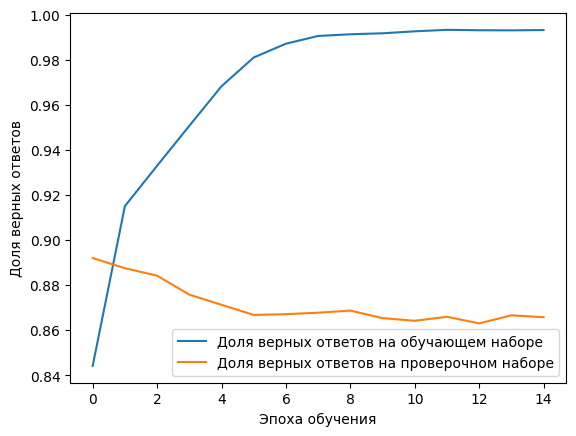

In [ ]:
plt.plot(history_cnn.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history_cnn.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

## Cеть LSTM

In [ ]:
model_lstm = keras.Sequential()
model_lstm.add(keras.layers.Embedding(num_words, 32, input_length=max_news_len))
model_lstm.add(keras.layers.LSTM(16))
model_lstm.add(keras.layers.Dense(4, activation='softmax'))

In [ ]:
model_lstm.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
model_lstm.summary()

Model: "sequential_52"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_52 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Создаем callback для сохранения нейронной сети на каждой эпохе, если качество работы на проверочном наборе данных улучшилось. Сеть сохраняется в файл `best_model.h5`

In [ ]:
# model_lstm_save_path = 'best_model_lstm.h5'
checkpoint_filepath_lstm = '/tmp/ckpt/checkpoint.model_lstm.keras'
checkpoint_callback_lstm = ModelCheckpoint(checkpoint_filepath_lstm,
                                      monitor='val_accuracy',
                                      save_best_only=True,
                                      verbose=1)

In [ ]:
history_lstm = model_lstm.fit(x_train,
                              y_train,
                              epochs=15,
                              batch_size=128,
                              validation_split=0.1,
                              callbacks=[checkpoint_callback_lstm])

Epoch 1/15
838/844 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7037 - loss: 0.7700
Epoch 1: val_accuracy improved from -inf to 0.89033, saving model to /tmp/ckpt/checkpoint.model_lstm.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7047 - loss: 0.7678 - val_accuracy: 0.8903 - val_loss: 0.3247
Epoch 2/15
836/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9148 - loss: 0.2728
Epoch 2: val_accuracy did not improve from 0.89033
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9148 - loss: 0.2729 - val_accuracy: 0.8903 - val_loss: 0.3163
Epoch 3/15
838/844 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9277 - loss: 0.2285
Epoch 3: val_accuracy did not improve from 0.89033
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9277 - loss: 0.2286 - val_accuracy: 0.8836 - val_loss: 0.3270
Epoch 4/15
841/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9343 - loss: 0.2047
Epoch 4: val_accuracy did not improve from 0.89033
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - ac

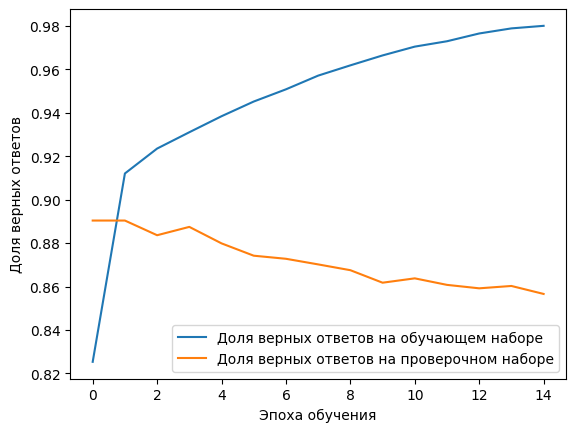

In [ ]:
plt.plot(history_lstm.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history_lstm.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

## Cеть GRU

In [ ]:
model_gru = keras.Sequential()
model_gru.add(keras.layers.Embedding(num_words, 32, input_length=max_news_len))
model_gru.add(keras.layers.GRU(16))
model_gru.add(keras.layers.Dense(4, activation='softmax'))

In [ ]:
model_gru.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
model_gru.summary()

Model: "sequential_53"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_53 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_15 (GRU)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Создаем callback для сохранения нейронной сети на каждой эпохе, если качество работы на проверочном наборе данных улучшилось. Сеть сохраняется в файл `best_model_gru.h5`

In [ ]:
# model_gru_save_path = 'best_model_gru.h5'
checkpoint_filepath_gru = '/tmp/ckpt/checkpoint.model_gru.keras'
checkpoint_callback_gru = ModelCheckpoint(checkpoint_filepath_gru,
                                      monitor='val_accuracy',
                                      save_best_only=True,
                                      verbose=1)

In [ ]:
history_gru = model_gru.fit(x_train,
                              y_train,
                              epochs=15,
                              batch_size=128,
                              validation_split=0.1,
                              callbacks=[checkpoint_callback_gru])

Epoch 1/15
841/844 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6643 - loss: 0.8252
Epoch 1: val_accuracy improved from -inf to 0.87842, saving model to /tmp/ckpt/checkpoint.model_gru.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6649 - loss: 0.8238 - val_accuracy: 0.8784 - val_loss: 0.3493
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9059 - loss: 0.2960
Epoch 2: val_accuracy improved from 0.87842 to 0.88558, saving model to /tmp/ckpt/checkpoint.model_gru.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9059 - loss: 0.2960 - val_accuracy: 0.8856 - val_loss: 0.3237
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9201 - loss: 0.2508
Epoch 3: val_accuracy did not improve from 0.88558
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9201 - loss: 0.2508 - val_accuracy: 0.8839 - val_loss: 0.3238
Epoch 4/15
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9296 - loss: 0.2197
Epoch 4: val_accuracy did not improve 

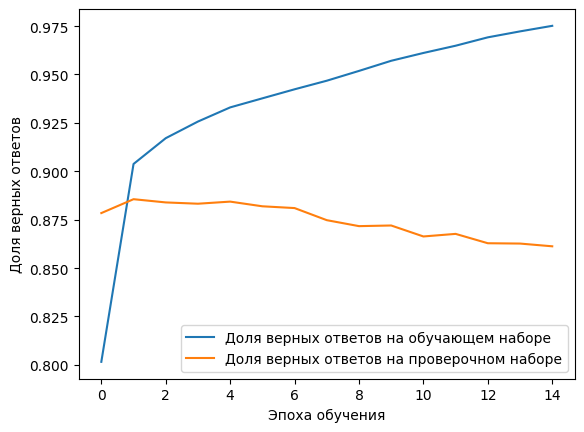

In [ ]:
plt.plot(history_gru.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history_gru.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

## Загружаем набор данных для тестирования

In [ ]:
test = pd.read_csv('test.csv',
                    header=None,
                    names=['class', 'title', 'text'])
test

,class,title,text
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...
...,...,...,...
7595,1,Around the world,Ukrainian presidential candidate Viktor Yushch...
7596,2,Void is filled with Clement,With the supply of attractive pitching options...
7597,2,Martinez leaves bitter,Like Roger Clemens did almost exactly eight ye...
7598,3,5 of arthritis patients in Singapore take Bext...,SINGAPORE : Doctors in the United States have ...


Преобразуем новости в числовое представление

Обратите внимание, что нужно использовать токенизатор, обученный на наборе данных train.

In [ ]:
test_sequences = tokenizer.texts_to_sequences(test['text'])

In [ ]:
x_test = pad_sequences(test_sequences, maxlen=max_news_len)

x_test[:5]

array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0, 2020, 3371,  449,   15, 6956,  252,   60,   33,
          28,  289,   12, 9088, 2184,  371,  169, 9284],
       [  92,  119,    4, 3472,    8,    1,  402,  134,   75, 5471, 1516,
        1227,    2, 3436,    8, 2744, 5220,  230,  936,   20, 2148,  117,
           1,   38,  561, 1974,    8,   14, 3957, 1218],
       [   2,   52, 5787,   18,    2, 4914,   15,    1,  525,    4, 4586,
         227,    2, 3922,    3, 1316,    2, 6888,    4, 2893,  576,   84,
          33,  758, 6515,    4,    1, 1013, 5154,    4],
       [9642, 1291,    6, 8714,   41,  671,   40, 2977,  177,    1,  108,
          26, 1027, 7300,   26,  760,    5, 3356,   40, 1271, 2450,   26,
        2170,   50, 3356,   26, 7415,    6, 9153,   26],
       [   0,    0,    0,    0,    0,    0,   39,  493, 7343,  832,  400,
         820,   28, 3827,    4,    1, 4474,   54, 9411,    1, 1273,   38,
        1230,    3, 1365,  348, 

Правильные ответы

In [ ]:
y_test = utils.to_categorical(test['class'] - 1, nb_classes)

y_test

array([[0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       ...,
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.]])

## Оцениваем качество работы сети на тестовом наборе данных

### Одномерная сверточная сеть

In [ ]:
model_cnn.load_weights(checkpoint_filepath_cnn)
model_cnn.evaluate(x_test, y_test, verbose=1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8892 - loss: 0.3340


[0.3118465840816498, 0.8931578993797302]

### Сеть LSTM

In [ ]:
model_lstm.load_weights(checkpoint_filepath_lstm)
model_lstm.evaluate(x_test, y_test, verbose=1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8828 - loss: 0.3559


[0.3337469696998596, 0.8915789723396301]

### Сеть GRU

In [ ]:
model_gru.load_weights(checkpoint_filepath_gru)
model_gru.evaluate(x_test, y_test, verbose=1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8864 - loss: 0.3485


[0.33086857199668884, 0.8903947472572327]

## Задание

1. Попробовать улучшить предсказание моделей за счет использования не только текста, но и заголовка новости.
При этом рекомендуется увеличить максимальню длину текста. <br/>
2. Проверить, как на качество предсказания влияет предобработка текста (удаление стоп-слов, пунктуации, лемматизация и др.)
3. Применить методы регуляризации для устранения переобучения моделей.


## Пробуем добавить к тексту заголовок новости + увеличим максимальную длину текста

### Заново предобрабатываем датасет

In [ ]:
longer_news = train['title'] + ' ' + train['text']
longer_news[:5]

,0
0,Wall St. Bears Claw Back Into the Black (Reute...
1,Carlyle Looks Toward Commercial Aerospace (Reu...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,Iraq Halts Oil Exports from Main Southern Pipe...
4,"Oil prices soar to all-time record, posing new..."


In [ ]:
new_max_news_len = 60

In [ ]:
vectorize_layer_1 = tf.keras.layers.TextVectorization(max_tokens=num_words,
    output_mode='int',
    output_sequence_length=new_max_news_len)

vectorize_layer_1.adapt(longer_news)
vectorize_layer_1.get_vocabulary()

['',
 '[UNK]',
 np.str_('the'),
 np.str_('to'),
 np.str_('a'),
 np.str_('of'),
 np.str_('in'),
 np.str_('and'),
 np.str_('on'),
 np.str_('for'),
 np.str_('39s'),
 np.str_('that'),
 np.str_('with'),
 np.str_('as'),
 np.str_('at'),
 np.str_('its'),
 np.str_('is'),
 np.str_('new'),
 np.str_('by'),
 np.str_('said'),
 np.str_('it'),
 np.str_('us'),
 np.str_('has'),
 np.str_('from'),
 np.str_('reuters'),
 np.str_('an'),
 np.str_('ap'),
 np.str_('his'),
 np.str_('will'),
 np.str_('after'),
 np.str_('was'),
 np.str_('be'),
 np.str_('over'),
 np.str_('have'),
 np.str_('their'),
 np.str_('are'),
 np.str_('up'),
 np.str_('but'),
 np.str_('first'),
 np.str_('more'),
 np.str_('two'),
 np.str_('he'),
 np.str_('this'),
 np.str_('world'),
 np.str_('monday'),
 np.str_('wednesday'),
 np.str_('tuesday'),
 np.str_('oil'),
 np.str_('out'),
 np.str_('thursday'),
 np.str_('company'),
 np.str_('one'),
 np.str_('not'),
 np.str_('against'),
 np.str_('friday'),
 np.str_('into'),
 np.str_('inc'),
 np.str_('about'

In [ ]:
tokenizer_1 = Tokenizer(num_words=num_words)
tokenizer_1.fit_on_texts(longer_news)
tokenizer_1.word_index

{'the': 1,
 'to': 2,
 'a': 3,
 'of': 4,
 'in': 5,
 'and': 6,
 'on': 7,
 'for': 8,
 '39': 9,
 's': 10,
 'that': 11,
 'with': 12,
 'as': 13,
 'at': 14,
 'its': 15,
 'is': 16,
 'new': 17,
 'by': 18,
 'said': 19,
 'it': 20,
 'reuters': 21,
 'has': 22,
 'from': 23,
 'an': 24,
 'ap': 25,
 'his': 26,
 'will': 27,
 'after': 28,
 'was': 29,
 'gt': 30,
 'us': 31,
 'lt': 32,
 'be': 33,
 'over': 34,
 'have': 35,
 'up': 36,
 'their': 37,
 'two': 38,
 'first': 39,
 'are': 40,
 'quot': 41,
 'year': 42,
 'but': 43,
 'more': 44,
 'he': 45,
 'u': 46,
 'this': 47,
 '1': 48,
 'one': 49,
 'world': 50,
 'monday': 51,
 'out': 52,
 'oil': 53,
 'wednesday': 54,
 'tuesday': 55,
 'thursday': 56,
 'company': 57,
 '2': 58,
 'not': 59,
 'against': 60,
 'inc': 61,
 'friday': 62,
 'than': 63,
 'into': 64,
 'last': 65,
 'about': 66,
 'b': 67,
 'york': 68,
 'they': 69,
 'who': 70,
 'three': 71,
 'yesterday': 72,
 'iraq': 73,
 'no': 74,
 'president': 75,
 'were': 76,
 'million': 77,
 'game': 78,
 'microsoft': 79,
 'been

In [ ]:
sequences_1 = tokenizer_1.texts_to_sequences(longer_news)

In [ ]:
x_train_1 = pad_sequences(sequences_1, maxlen=new_max_news_len)

x_train_1[:5]

array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,  442,  441, 1681,  108,
          64,    1,  850,   21,   21,  753, 8196,  442, 6640, 2927,    4,
        5810,   40, 4049,  797,  332],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0, 1099,  877, 1303, 4245,   21,   21,  920,  811,
         352,   99,  102,   22,    3, 4521,    8,  508,  509,    6, 1520,
        2176,    5,    1,  530,  247,   22, 3936, 2293,   15, 6560,    7,
         212,  368,    4,    1,  128],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,   53,    6,  3

### Заново обучаем модели

#### Свёрточная

In [ ]:
model_cnn_1 = keras.Sequential()
model_cnn_1.add(keras.layers.Embedding(num_words, 32, input_length=new_max_news_len))
model_cnn_1.add(keras.layers.Conv1D(250, 5, padding='valid', activation='relu'))
model_cnn_1.add(keras.layers.GlobalMaxPooling1D())
model_cnn_1.add(keras.layers.Dense(128, activation='relu'))
model_cnn_1.add(keras.layers.Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model_cnn_1.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# model_cnn_save_path = 'best_model_cnn1.h5'
checkpoint_filepath_cnn_1 = '/tmp/ckpt/checkpoint.model_cnn_1.keras'
checkpoint_callback_cnn_1 = ModelCheckpoint(checkpoint_filepath_cnn_1,
                                      monitor='val_accuracy',
                                      save_best_only=True,
                                      verbose=1)

In [ ]:
history_cnn_1 = model_cnn_1.fit(x_train_1,
                            y_train,
                            epochs=15,
                            batch_size=128,
                            validation_split=0.1,
                            callbacks=[checkpoint_callback_cnn_1])

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7542 - loss: 0.6124
Epoch 1: val_accuracy improved from -inf to 0.90975, saving model to /tmp/ckpt/checkpoint.model_cnn_1.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7543 - loss: 0.6121 - val_accuracy: 0.9097 - val_loss: 0.2529
Epoch 2/15
837/844 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9342 - loss: 0.1942
Epoch 2: val_accuracy did not improve from 0.90975
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9342 - loss: 0.1942 - val_accuracy: 0.9073 - val_loss: 0.2631
Epoch 3/15
837/844 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9514 - loss: 0.1412
Epoch 3: val_accuracy did not improve from 0.90975
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9514 - loss: 0.1412 - val_accuracy: 0.9042 - val_loss: 0.2833
Epoch 4/15
833/844 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9679 - loss: 0.0943
Epoch 4: val_accuracy did not improve from 0.90975
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - a

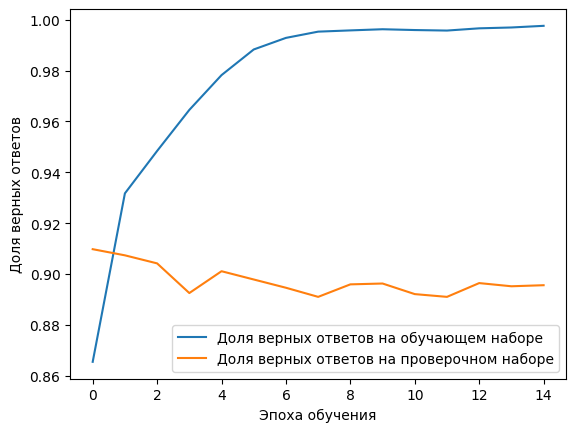

In [ ]:
plt.plot(history_cnn_1.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history_cnn_1.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

#### LSTM

In [ ]:
model_lstm_1 = keras.Sequential()
model_lstm_1.add(keras.layers.Embedding(num_words, 32, input_length=new_max_news_len))
model_lstm_1.add(keras.layers.LSTM(16))
model_lstm_1.add(keras.layers.Dense(4, activation='softmax'))

In [ ]:
model_lstm_1.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# model_lstm_save_path = 'best_model_lstm_1.h5'
checkpoint_filepath_lstm_1 = '/tmp/ckpt/checkpoint.model_lstm_1.keras'
checkpoint_callback_lstm_1 = ModelCheckpoint(checkpoint_filepath_lstm_1,
                                      monitor='val_accuracy',
                                      save_best_only=True,
                                      verbose=1)

In [ ]:
history_lstm_1 = model_lstm_1.fit(x_train_1,
                              y_train,
                              epochs=15,
                              batch_size=128,
                              validation_split=0.1,
                              callbacks=[checkpoint_callback_lstm_1])

Epoch 1/15
838/844 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7310 - loss: 0.7495
Epoch 1: val_accuracy improved from -inf to 0.90342, saving model to /tmp/ckpt/checkpoint.model_lstm_1.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7319 - loss: 0.7472 - val_accuracy: 0.9034 - val_loss: 0.2849
Epoch 2/15
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9253 - loss: 0.2415
Epoch 2: val_accuracy did not improve from 0.90342
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9253 - loss: 0.2415 - val_accuracy: 0.9010 - val_loss: 0.2860
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9393 - loss: 0.1952
Epoch 3: val_accuracy did not improve from 0.90342
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9393 - loss: 0.1952 - val_accuracy: 0.9011 - val_loss: 0.2875
Epoch 4/15
842/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9466 - loss: 0.1662
Epoch 4: val_accuracy did not improve from 0.90342
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - 

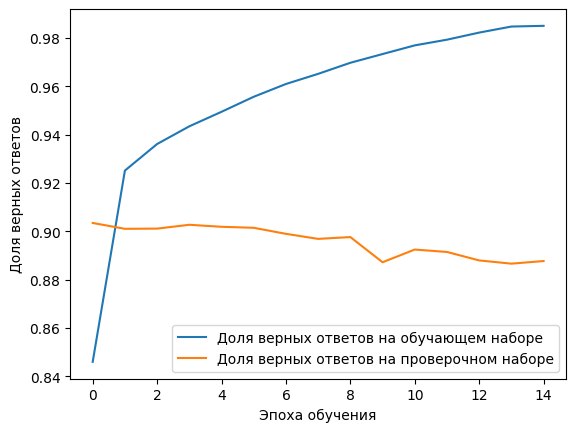

In [ ]:
plt.plot(history_lstm_1.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history_lstm_1.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

#### GRU

In [ ]:
model_gru_1 = keras.Sequential()
model_gru_1.add(keras.layers.Embedding(num_words, 32, input_length=new_max_news_len))
model_gru_1.add(keras.layers.GRU(16))
model_gru_1.add(keras.layers.Dense(4, activation='softmax'))

In [ ]:
model_gru_1.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# model_gru_save_path = 'best_model_gru_1.h5'
checkpoint_filepath_gru_1 = '/tmp/ckpt/checkpoint.model_gru_1.keras'
checkpoint_callback_gru_1 = ModelCheckpoint(checkpoint_filepath_gru_1,
                                      monitor='val_accuracy',
                                      save_best_only=True,
                                      verbose=1)

In [ ]:
history_gru_1 = model_gru_1.fit(x_train_1,
                              y_train,
                              epochs=15,
                              batch_size=128,
                              validation_split=0.1,
                              callbacks=[checkpoint_callback_gru_1])

Epoch 1/15
842/844 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6809 - loss: 0.8116
Epoch 1: val_accuracy improved from -inf to 0.89917, saving model to /tmp/ckpt/checkpoint.model_gru_1.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.6814 - loss: 0.8106 - val_accuracy: 0.8992 - val_loss: 0.3001
Epoch 2/15
840/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9206 - loss: 0.2520
Epoch 2: val_accuracy improved from 0.89917 to 0.90425, saving model to /tmp/ckpt/checkpoint.model_gru_1.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9206 - loss: 0.2520 - val_accuracy: 0.9043 - val_loss: 0.2669
Epoch 3/15
837/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9367 - loss: 0.2016
Epoch 3: val_accuracy did not improve from 0.90425
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9367 - loss: 0.2017 - val_accuracy: 0.8975 - val_loss: 0.2882
Epoch 4/15
839/844 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9425 - loss: 0.1797
Epoch 4: val_accuracy did not impro

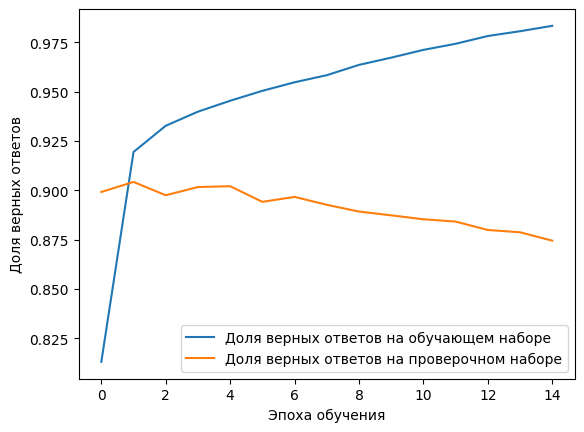

In [ ]:
plt.plot(history_gru_1.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history_gru_1.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

### Проверяем на тестовых данных

In [ ]:
test_sequences_1 = tokenizer_1.texts_to_sequences(test['text'])

x_test_1 = pad_sequences(test_sequences_1, maxlen=new_max_news_len)

x_test_1[:5]

array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
        1804, 4122,  435,   14, 6909,  243,   69,   40,   28,  177,   12,
        7749, 2509,  352,  199, 9385],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,  183,   89,  746,  614,    3,  105,  116,    4,
        4029,    8,    1,  407,  131,   77, 6144, 1339, 1078,    3, 3615,
           8, 3373, 6111,  183,  801,   22, 2496,  147,    1,   39,  439,
        1778,    8,   15, 4415, 1173],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,   

In [ ]:
model_cnn_1.load_weights(checkpoint_filepath_cnn_1)
model_cnn_1.evaluate(x_test_1, y_test, verbose=1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8972 - loss: 0.3099


[0.2956238090991974, 0.8980262875556946]

In [ ]:
model_lstm_1.load_weights(checkpoint_filepath_lstm_1)
model_lstm_1.evaluate(x_test_1, y_test, verbose=1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8793 - loss: 0.3565


[0.33439379930496216, 0.8877631425857544]

In [ ]:
model_gru_1.load_weights(checkpoint_filepath_gru_1)
model_gru_1.evaluate(x_test_1, y_test, verbose=1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8885 - loss: 0.3383


[0.3179928660392761, 0.893815815448761]

## Стоп-слова и пунктуация

**Стоп-слова** - это слова, которые часто встречаются практически в любом тексте и не несут полезной информации о конретном документе. Для модели это просто шум. А шум нужно убирать. По аналогичной причине убирают и пунктуацию.

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
# импортируем стоп-слова из библиотеки nltk
from nltk.corpus import stopwords

# посмотрим на стоп-слова для английского языка
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

*Знаки* пунктуации лучше импортировать из модуля **String**. В нем хранятся различные наборы констант для работы со строками (пунктуация, алфавит и др.).

In [ ]:
from string import punctuation
punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'



Объединим стоп-слова и знаки пунктуации вместе и запишем в переменную noise:


In [ ]:
noise = stopwords.words('english') + list(punctuation)

In [ ]:
# Оставляем только слова не из noise

news_clean = []

for text in longer_news:
    tokens = text.lower().split()
    tokens = [word for word in tokens if word not in noise]
    clean_text = " ".join(tokens)
    news_clean.append(clean_text)


In [ ]:
vectorize_layer_2 = tf.keras.layers.TextVectorization(max_tokens=num_words,
    output_mode='int',
    output_sequence_length=new_max_news_len)

vectorize_layer_2.adapt(news_clean)
vectorize_layer_2.get_vocabulary()

['',
 '[UNK]',
 np.str_('39s'),
 np.str_('new'),
 np.str_('said'),
 np.str_('us'),
 np.str_('reuters'),
 np.str_('ap'),
 np.str_('first'),
 np.str_('two'),
 np.str_('world'),
 np.str_('monday'),
 np.str_('wednesday'),
 np.str_('tuesday'),
 np.str_('oil'),
 np.str_('thursday'),
 np.str_('company'),
 np.str_('one'),
 np.str_('friday'),
 np.str_('inc'),
 np.str_('last'),
 np.str_('39'),
 np.str_('york'),
 np.str_('yesterday'),
 np.str_('year'),
 np.str_('iraq'),
 np.str_('president'),
 np.str_('microsoft'),
 np.str_('million'),
 np.str_('says'),
 np.str_('united'),
 np.str_('game'),
 np.str_('week'),
 np.str_('years'),
 np.str_('prices'),
 np.str_('corp'),
 np.str_('three'),
 np.str_('could'),
 np.str_('would'),
 np.str_('sunday'),
 np.str_('security'),
 np.str_('time'),
 np.str_('group'),
 np.str_('people'),
 np.str_('government'),
 np.str_('today'),
 np.str_('may'),
 np.str_('afp'),
 np.str_('percent'),
 np.str_('quot'),
 np.str_('software'),
 np.str_('win'),
 np.str_('next'),
 np.str_(

In [ ]:
tokenizer_2 = Tokenizer(num_words=num_words)
tokenizer_2.fit_on_texts(news_clean)
tokenizer_2.word_index

{'39': 1,
 's': 2,
 'new': 3,
 'said': 4,
 'reuters': 5,
 'ap': 6,
 'gt': 7,
 'us': 8,
 'lt': 9,
 'two': 10,
 'first': 11,
 'quot': 12,
 'year': 13,
 'u': 14,
 '1': 15,
 'one': 16,
 'world': 17,
 'monday': 18,
 'oil': 19,
 'wednesday': 20,
 'tuesday': 21,
 'thursday': 22,
 'company': 23,
 '2': 24,
 'inc': 25,
 'friday': 26,
 'last': 27,
 'b': 28,
 'york': 29,
 'three': 30,
 'yesterday': 31,
 'a': 32,
 'iraq': 33,
 'president': 34,
 'million': 35,
 'game': 36,
 'microsoft': 37,
 'time': 38,
 'week': 39,
 'says': 40,
 'corp': 41,
 'united': 42,
 'stocks': 43,
 'com': 44,
 'prices': 45,
 'could': 46,
 'would': 47,
 '3': 48,
 'security': 49,
 'government': 50,
 'sunday': 51,
 'years': 52,
 'n': 53,
 'group': 54,
 'people': 55,
 'today': 56,
 'may': 57,
 'second': 58,
 'afp': 59,
 'percent': 60,
 'back': 61,
 'software': 62,
 'next': 63,
 'season': 64,
 'win': 65,
 'third': 66,
 'day': 67,
 'team': 68,
 'internet': 69,
 'quarter': 70,
 'saturday': 71,
 'high': 72,
 '6': 73,
 'night': 74,
 '

In [ ]:
sequences_2 = tokenizer_2.texts_to_sequences(news_clean)

In [ ]:
x_train_2 = pad_sequences(sequences_2, maxlen=new_max_news_len)

x_train_2[:5]

array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
         365,  364, 1593,   61,  765,    5,    5,  668, 8137,  365, 6573,
        2836, 5741, 3970,  712, 1293],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0, 1010,  791, 1214, 4169,    5,    5,  832,  725,  278,
          54, 5165, 4446,  430,  431, 1430, 2084,  451,  183, 3856, 2201,
        2926, 6493,  152,  294,   78],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,   

### И еще раз обучаем модели

#### Свёрточная

In [ ]:
model_cnn_2 = keras.Sequential()
model_cnn_2.add(keras.layers.Embedding(num_words, 32, input_length=new_max_news_len))
model_cnn_2.add(keras.layers.Conv1D(250, 5, padding='valid', activation='relu'))
model_cnn_2.add(keras.layers.GlobalMaxPooling1D())
model_cnn_2.add(keras.layers.Dense(128, activation='relu'))
model_cnn_2.add(keras.layers.Dense(4, activation='softmax'))

In [ ]:
model_cnn_2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# model_cnn_save_path = 'best_model_cnn2.h5'
checkpoint_filepath_cnn_2 = '/tmp/ckpt/checkpoint.model_cnn_2.keras'
checkpoint_callback_cnn_2 = ModelCheckpoint(checkpoint_filepath_cnn_2,
                                      monitor='val_accuracy',
                                      save_best_only=True,
                                      verbose=1)

In [ ]:
history_cnn_2 = model_cnn_2.fit(x_train_2,
                            y_train,
                            epochs=15,
                            batch_size=128,
                            validation_split=0.1,
                            callbacks=[checkpoint_callback_cnn_2])

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7741 - loss: 0.5795
Epoch 1: val_accuracy improved from -inf to 0.91083, saving model to /tmp/ckpt/checkpoint.model_cnn_2.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7742 - loss: 0.5792 - val_accuracy: 0.9108 - val_loss: 0.2488
Epoch 2/15
831/844 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9364 - loss: 0.1870
Epoch 2: val_accuracy did not improve from 0.91083
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9364 - loss: 0.1871 - val_accuracy: 0.9082 - val_loss: 0.2565
Epoch 3/15
833/844 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9546 - loss: 0.1328
Epoch 3: val_accuracy did not improve from 0.91083
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9546 - loss: 0.1330 - val_accuracy: 0.9043 - val_loss: 0.2832
Epoch 4/15
829/844 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9705 - loss: 0.0870
Epoch 4: val_accuracy did not improve from 0.91083
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - a

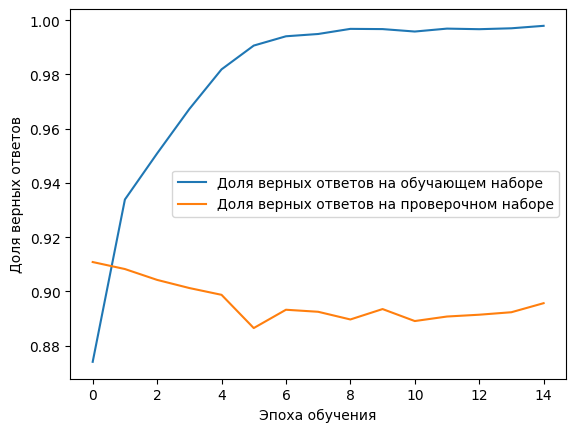

In [ ]:
plt.plot(history_cnn_2.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history_cnn_2.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

#### LSTM

In [ ]:
model_lstm_2 = keras.Sequential()
model_lstm_2.add(keras.layers.Embedding(num_words, 32, input_length=new_max_news_len))
model_lstm_2.add(keras.layers.LSTM(16))
model_lstm_2.add(keras.layers.Dense(4, activation='softmax'))

In [ ]:
model_lstm_2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# model_lstm_save_path = 'best_model_lstm_2.h5'
checkpoint_filepath_lstm_2 = '/tmp/ckpt/checkpoint.model_lstm_2.keras'
checkpoint_callback_lstm_2 = ModelCheckpoint(checkpoint_filepath_lstm_2,
                                      monitor='val_accuracy',
                                      save_best_only=True,
                                      verbose=1)

In [ ]:
history_lstm_2 = model_lstm_2.fit(x_train_2,
                              y_train,
                              epochs=15,
                              batch_size=128,
                              validation_split=0.1,
                              callbacks=[checkpoint_callback_lstm_2])

Epoch 1/15
841/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7167 - loss: 0.7271
Epoch 1: val_accuracy improved from -inf to 0.90817, saving model to /tmp/ckpt/checkpoint.model_lstm_2.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7173 - loss: 0.7259 - val_accuracy: 0.9082 - val_loss: 0.2774
Epoch 2/15
840/844 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9297 - loss: 0.2338
Epoch 2: val_accuracy did not improve from 0.90817
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9297 - loss: 0.2338 - val_accuracy: 0.9068 - val_loss: 0.2732
Epoch 3/15
841/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9428 - loss: 0.1852
Epoch 3: val_accuracy did not improve from 0.90817
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9428 - loss: 0.1852 - val_accuracy: 0.9061 - val_loss: 0.2688
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9511 - loss: 0.1555
Epoch 4: val_accuracy did not improve from 0.90817
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - 

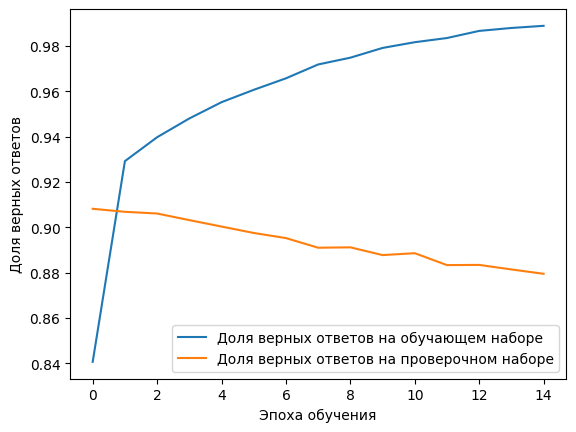

In [ ]:
plt.plot(history_lstm_2.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history_lstm_2.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

#### GRU

In [ ]:
model_gru_2 = keras.Sequential()
model_gru_2.add(keras.layers.Embedding(num_words, 32, input_length=new_max_news_len))
model_gru_2.add(keras.layers.GRU(16))
model_gru_2.add(keras.layers.Dense(4, activation='softmax'))

In [ ]:
model_gru_2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# model_gru_save_path = 'best_model_gru_2.h5'
checkpoint_filepath_gru_2 = '/tmp/ckpt/checkpoint.model_gru_2.keras'
checkpoint_callback_gru_2 = ModelCheckpoint(checkpoint_filepath_gru_2,
                                      monitor='val_accuracy',
                                      save_best_only=True,
                                      verbose=1)

In [ ]:
history_gru_2 = model_gru_2.fit(x_train_2,
                              y_train,
                              epochs=15,
                              batch_size=128,
                              validation_split=0.1,
                              callbacks=[checkpoint_callback_gru_2])

Epoch 1/15
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7161 - loss: 0.7870
Epoch 1: val_accuracy improved from -inf to 0.90575, saving model to /tmp/ckpt/checkpoint.model_gru_2.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7164 - loss: 0.7863 - val_accuracy: 0.9057 - val_loss: 0.2768
Epoch 2/15
842/844 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9298 - loss: 0.2285
Epoch 2: val_accuracy improved from 0.90575 to 0.90667, saving model to /tmp/ckpt/checkpoint.model_gru_2.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9298 - loss: 0.2285 - val_accuracy: 0.9067 - val_loss: 0.2697
Epoch 3/15
839/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9404 - loss: 0.1909
Epoch 3: val_accuracy improved from 0.90667 to 0.90700, saving model to /tmp/ckpt/checkpoint.model_gru_2.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9403 - loss: 0.1910 - val_accuracy: 0.9070 - val_loss: 0.2752
Epoch 4/15
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accurac

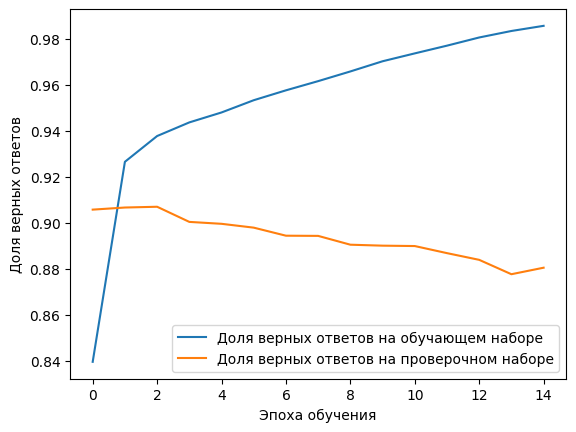

In [ ]:
plt.plot(history_gru_2.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history_gru_2.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

### Проверяем на тестовых данных

In [ ]:
test_sequences_2 = tokenizer_2.texts_to_sequences(test['text'])

x_test_2 = pad_sequences(test_sequences_2, maxlen=new_max_news_len)

x_test_2[:5]

array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
        1716, 4046,  358, 2940, 6846,  180, 5934, 4125, 3243,  121, 2943,
        7689, 2419,  278,  140, 9323],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,  126,   44,  661,  535,   32,   58,   68,  761,
        3950, 1013,  190,  333,   81,   35, 6077, 1248,  989,   32, 3535,
        1013, 3292, 6044,  126,  716, 4511, 2406,   94,  190,   11,  362,
        1690, 1013, 2926, 4339, 1085],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,   

In [ ]:
model_cnn_2.load_weights(checkpoint_filepath_cnn_2)
model_cnn_2.evaluate(x_test_2, y_test, verbose=1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7983 - loss: 0.5168


[0.5103085041046143, 0.7939473390579224]

In [ ]:
model_lstm_2.load_weights(checkpoint_filepath_lstm_2)
model_lstm_2.evaluate(x_test_2, y_test, verbose=1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8258 - loss: 0.5138


[0.5099401473999023, 0.8219736814498901]

In [ ]:
model_gru_2.load_weights(checkpoint_filepath_gru_2)
model_gru_2.evaluate(x_test_2, y_test, verbose=1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7418 - loss: 0.7685


[0.7495254874229431, 0.7410526275634766]

## Лемматизация

**Лемматизация** – это сведение разных форм одного слова к начальной форме – **лемме**. Почему это хорошо?
* Во-первых, естественно рассматривать как отдельный признак каждое *слово*, а не каждую его отдельную форму.
* Во-вторых, некоторые стоп-слова стоят только в начальной форме, и без лематизации выкидываем мы только её.

In [ ]:
from nltk.stem import WordNetLemmatizer

In [ ]:
lemmatizer = WordNetLemmatizer()

In [ ]:
lem_news = list(lemmatizer.lemmatize(word) for word in longer_news)

### Делаем новый токенизатор

In [ ]:
vectorize_layer_3 = tf.keras.layers.TextVectorization(max_tokens=num_words,
    output_mode='int',
    output_sequence_length=new_max_news_len)

vectorize_layer_3.adapt(lem_news)
vectorize_layer_3.get_vocabulary()

['',
 '[UNK]',
 np.str_('the'),
 np.str_('to'),
 np.str_('a'),
 np.str_('of'),
 np.str_('in'),
 np.str_('and'),
 np.str_('on'),
 np.str_('for'),
 np.str_('39s'),
 np.str_('that'),
 np.str_('with'),
 np.str_('as'),
 np.str_('at'),
 np.str_('its'),
 np.str_('is'),
 np.str_('new'),
 np.str_('by'),
 np.str_('said'),
 np.str_('it'),
 np.str_('us'),
 np.str_('has'),
 np.str_('from'),
 np.str_('reuters'),
 np.str_('an'),
 np.str_('ap'),
 np.str_('his'),
 np.str_('will'),
 np.str_('after'),
 np.str_('was'),
 np.str_('be'),
 np.str_('over'),
 np.str_('have'),
 np.str_('their'),
 np.str_('are'),
 np.str_('up'),
 np.str_('but'),
 np.str_('first'),
 np.str_('more'),
 np.str_('two'),
 np.str_('he'),
 np.str_('this'),
 np.str_('world'),
 np.str_('monday'),
 np.str_('wednesday'),
 np.str_('tuesday'),
 np.str_('oil'),
 np.str_('out'),
 np.str_('thursday'),
 np.str_('company'),
 np.str_('one'),
 np.str_('not'),
 np.str_('against'),
 np.str_('friday'),
 np.str_('into'),
 np.str_('inc'),
 np.str_('about'

In [ ]:
tokenizer_3 = Tokenizer(num_words=num_words)
tokenizer_3.fit_on_texts(lem_news)
tokenizer_3.word_index

{'the': 1,
 'to': 2,
 'a': 3,
 'of': 4,
 'in': 5,
 'and': 6,
 'on': 7,
 'for': 8,
 '39': 9,
 's': 10,
 'that': 11,
 'with': 12,
 'as': 13,
 'at': 14,
 'its': 15,
 'is': 16,
 'new': 17,
 'by': 18,
 'said': 19,
 'it': 20,
 'reuters': 21,
 'has': 22,
 'from': 23,
 'an': 24,
 'ap': 25,
 'his': 26,
 'will': 27,
 'after': 28,
 'was': 29,
 'gt': 30,
 'us': 31,
 'lt': 32,
 'be': 33,
 'over': 34,
 'have': 35,
 'up': 36,
 'their': 37,
 'two': 38,
 'first': 39,
 'are': 40,
 'quot': 41,
 'year': 42,
 'but': 43,
 'more': 44,
 'he': 45,
 'u': 46,
 'this': 47,
 '1': 48,
 'one': 49,
 'world': 50,
 'monday': 51,
 'out': 52,
 'oil': 53,
 'wednesday': 54,
 'tuesday': 55,
 'thursday': 56,
 'company': 57,
 '2': 58,
 'not': 59,
 'against': 60,
 'inc': 61,
 'friday': 62,
 'than': 63,
 'into': 64,
 'last': 65,
 'about': 66,
 'b': 67,
 'york': 68,
 'they': 69,
 'who': 70,
 'three': 71,
 'yesterday': 72,
 'iraq': 73,
 'no': 74,
 'president': 75,
 'were': 76,
 'million': 77,
 'game': 78,
 'microsoft': 79,
 'been

In [ ]:
sequences_3 = tokenizer_3.texts_to_sequences(lem_news)

In [ ]:
x_train_3 = pad_sequences(sequences_3, maxlen=new_max_news_len)

x_train_3[:5]

array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,  442,  441, 1681,  108,
          64,    1,  850,   21,   21,  753, 8196,  442, 6640, 2927,    4,
        5810,   40, 4049,  797,  332],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0, 1099,  877, 1303, 4245,   21,   21,  920,  811,
         352,   99,  102,   22,    3, 4521,    8,  508,  509,    6, 1520,
        2176,    5,    1,  530,  247,   22, 3936, 2293,   15, 6560,    7,
         212,  368,    4,    1,  128],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,   53,    6,  3

### Переобучаем модели

#### Свёрточная

In [ ]:
model_cnn_3 = keras.Sequential()
model_cnn_3.add(keras.layers.Embedding(num_words, 32, input_length=new_max_news_len))
model_cnn_3.add(keras.layers.Conv1D(250, 5, padding='valid', activation='relu'))
model_cnn_3.add(keras.layers.GlobalMaxPooling1D())
model_cnn_3.add(keras.layers.Dense(128, activation='relu'))
model_cnn_3.add(keras.layers.Dense(4, activation='softmax'))

In [ ]:
model_cnn_3.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# model_cnn_save_path = 'best_model_cnn_3.h5'
checkpoint_filepath_cnn_3 = '/tmp/ckpt/checkpoint.model_cnn_3.keras'
checkpoint_callback_cnn_3 = ModelCheckpoint(checkpoint_filepath_cnn_3,
                                      monitor='val_accuracy',
                                      save_best_only=True,
                                      verbose=1)

In [ ]:
history_cnn_3 = model_cnn_3.fit(x_train_3,
                            y_train,
                            epochs=15,
                            batch_size=128,
                            validation_split=0.1,
                            callbacks=[checkpoint_callback_cnn_3])

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7575 - loss: 0.6132
Epoch 1: val_accuracy improved from -inf to 0.91108, saving model to /tmp/ckpt/checkpoint.model_cnn_3.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7577 - loss: 0.6129 - val_accuracy: 0.9111 - val_loss: 0.2513
Epoch 2/15
830/844 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9350 - loss: 0.1926
Epoch 2: val_accuracy did not improve from 0.91108
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9350 - loss: 0.1926 - val_accuracy: 0.9038 - val_loss: 0.2705
Epoch 3/15
840/844 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9523 - loss: 0.1371
Epoch 3: val_accuracy did not improve from 0.91108
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9522 - loss: 0.1371 - val_accuracy: 0.9059 - val_loss: 0.2841
Epoch 4/15
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9690 - loss: 0.0920
Epoch 4: val_accuracy did not improve from 0.91108
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - a

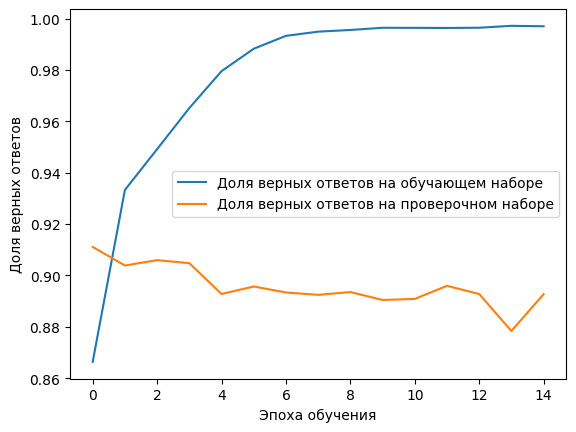

In [ ]:
plt.plot(history_cnn_3.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history_cnn_3.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

#### LSTM

In [ ]:
model_lstm_3 = keras.Sequential()
model_lstm_3.add(keras.layers.Embedding(num_words, 32, input_length=new_max_news_len))
model_lstm_3.add(keras.layers.LSTM(16))
model_lstm_3.add(keras.layers.Dense(4, activation='softmax'))

In [ ]:
model_lstm_3.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# model_lstm_save_path = 'best_model_lstm_3.h5'
checkpoint_filepath_lstm_3 = '/tmp/ckpt/checkpoint.model_lstm_3.keras'
checkpoint_callback_lstm_3 = ModelCheckpoint(checkpoint_filepath_lstm_3,
                                      monitor='val_accuracy',
                                      save_best_only=True,
                                      verbose=1)

In [ ]:
history_lstm_3 = model_lstm_3.fit(x_train_3,
                              y_train,
                              epochs=15,
                              batch_size=128,
                              validation_split=0.1,
                              callbacks=[checkpoint_callback_lstm_3])

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6896 - loss: 0.7913
Epoch 1: val_accuracy improved from -inf to 0.90267, saving model to /tmp/ckpt/checkpoint.model_lstm_3.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.6898 - loss: 0.7910 - val_accuracy: 0.9027 - val_loss: 0.2902
Epoch 2/15
842/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9252 - loss: 0.2480
Epoch 2: val_accuracy improved from 0.90267 to 0.91008, saving model to /tmp/ckpt/checkpoint.model_lstm_3.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9252 - loss: 0.2480 - val_accuracy: 0.9101 - val_loss: 0.2737
Epoch 3/15
837/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9380 - loss: 0.2024
Epoch 3: val_accuracy did not improve from 0.91008
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9380 - loss: 0.2024 - val_accuracy: 0.9025 - val_loss: 0.2877
Epoch 4/15
839/844 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9468 - loss: 0.1709
Epoch 4: val_accuracy did not im

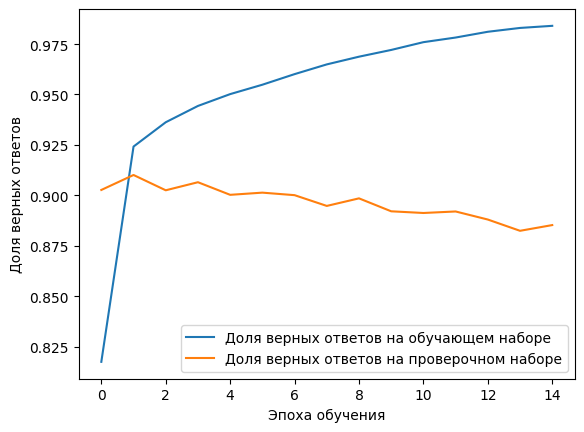

In [ ]:
plt.plot(history_lstm_3.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history_lstm_3.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

#### GRU

In [ ]:
model_gru_3 = keras.Sequential()
model_gru_3.add(keras.layers.Embedding(num_words, 32, input_length=new_max_news_len))
model_gru_3.add(keras.layers.GRU(16))
model_gru_3.add(keras.layers.Dense(4, activation='softmax'))

In [ ]:
model_gru_3.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# model_gru_save_path = 'best_model_gru_3.h5'
checkpoint_filepath_gru_3 = '/tmp/ckpt/checkpoint.model_gru_3.keras'
checkpoint_callback_gru_3 = ModelCheckpoint(checkpoint_filepath_gru_3,
                                      monitor='val_accuracy',
                                      save_best_only=True,
                                      verbose=1)

In [ ]:
history_gru_3 = model_gru_3.fit(x_train_3,
                              y_train,
                              epochs=15,
                              batch_size=128,
                              validation_split=0.1,
                              callbacks=[checkpoint_callback_gru_3])

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6712 - loss: 0.7971
Epoch 1: val_accuracy improved from -inf to 0.90517, saving model to /tmp/ckpt/checkpoint.model_gru_3.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6714 - loss: 0.7967 - val_accuracy: 0.9052 - val_loss: 0.2832
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9223 - loss: 0.2455
Epoch 2: val_accuracy improved from 0.90517 to 0.90708, saving model to /tmp/ckpt/checkpoint.model_gru_3.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9223 - loss: 0.2455 - val_accuracy: 0.9071 - val_loss: 0.2679
Epoch 3/15
841/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9385 - loss: 0.1987
Epoch 3: val_accuracy did not improve from 0.90708
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9385 - loss: 0.1987 - val_accuracy: 0.9057 - val_loss: 0.2655
Epoch 4/15
837/844 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9447 - loss: 0.1760
Epoch 4: val_accuracy did not impro

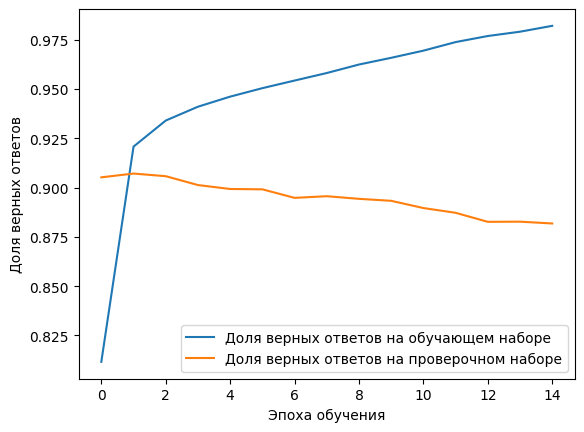

In [ ]:
plt.plot(history_gru_3.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history_gru_3.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

### Проверяем на тестовых данных

In [ ]:
test_sequences_3 = tokenizer_3.texts_to_sequences(test['text'])

x_test_3 = pad_sequences(test_sequences_3, maxlen=new_max_news_len)

x_test_3[:5]

array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
        1804, 4122,  435,   14, 6909,  243,   69,   40,   28,  177,   12,
        7749, 2509,  352,  199, 9385],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,  183,   89,  746,  614,    3,  105,  116,    4,
        4029,    8,    1,  407,  131,   77, 6144, 1339, 1078,    3, 3615,
           8, 3373, 6111,  183,  801,   22, 2496,  147,    1,   39,  439,
        1778,    8,   15, 4415, 1173],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,   

In [ ]:
model_cnn_3.load_weights(checkpoint_filepath_cnn_3)
model_cnn_3.evaluate(x_test_3, y_test, verbose=1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8891 - loss: 0.3240


[0.29971903562545776, 0.8965789675712585]

In [ ]:
model_lstm_3.load_weights(checkpoint_filepath_lstm_3)
model_lstm_3.evaluate(x_test_3, y_test, verbose=1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8944 - loss: 0.3268


[0.3088304102420807, 0.8971052765846252]

In [ ]:
model_gru_3.load_weights(checkpoint_filepath_gru_3)
model_gru_3.evaluate(x_test_3, y_test, verbose=1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8934 - loss: 0.3290


[0.31151434779167175, 0.8971052765846252]

## Регуляризация
Выберем несколько моделей из каждой группы и применим к ним регуляризацию

По графикам обучения видно, что сверточные неронные сети наиболее склонны к переобучению, соответственно к ним и попробуем применить регуляризацию

### С базовой предобработкой

In [ ]:
model_cnn = keras.Sequential()
model_cnn.add(keras.layers.Embedding(num_words, 32, input_length=max_news_len))
model_cnn.add(keras.layers.Conv1D(250, 5, padding='valid', activation='relu'))
model_cnn.add(keras.layers.Dropout(0.3))
model_cnn.add(keras.layers.GlobalMaxPooling1D())
model_cnn.add(keras.layers.Dense(128, activation='relu'))
model_cnn.add(keras.layers.Dropout(0.5))
model_cnn.add(keras.layers.Dense(4, activation='softmax'))

In [ ]:
model_cnn.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history_cnn = model_cnn.fit(x_train,
                            y_train,
                            epochs=5,
                            batch_size=128,
                            validation_split=0.1,
                            callbacks=[checkpoint_callback_cnn])

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6961 - loss: 0.7260
Epoch 1: val_accuracy did not improve from 0.89200
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6963 - loss: 0.7257 - val_accuracy: 0.8865 - val_loss: 0.3389
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9112 - loss: 0.2705
Epoch 2: val_accuracy did not improve from 0.89200
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9112 - loss: 0.2705 - val_accuracy: 0.8842 - val_loss: 0.3163
Epoch 3/5
833/844 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9253 - loss: 0.2223
Epoch 3: val_accuracy did not improve from 0.89200
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9252 - loss: 0.2224 - val_accuracy: 0.8803 - val_loss: 0.3243
Epoch 4/5
839/844 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9377 - loss: 0.1819
Epoch 4: val_accuracy did not improve from 0.89200
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9377 - loss: 0.1820 - val_accuracy: 0.8792 - val_

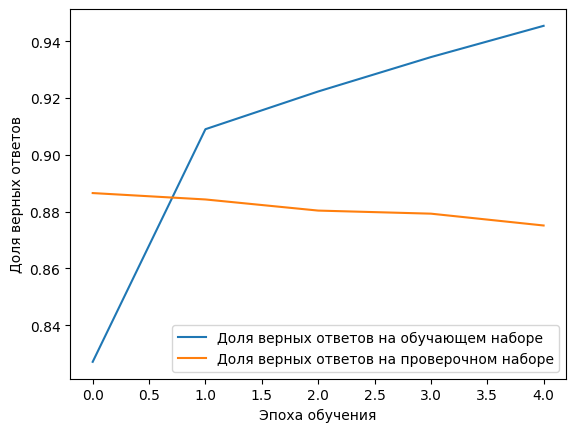

In [ ]:
plt.plot(history_cnn.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history_cnn.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

In [ ]:
model_cnn.evaluate(x_test, y_test, verbose=1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8778 - loss: 0.3773


[0.3598794639110565, 0.8857894539833069]

### Текст + заголовок

In [ ]:
model_cnn_1 = keras.Sequential()
model_cnn_1.add(keras.layers.Embedding(num_words, 32, input_length=new_max_news_len))
model_cnn_1.add(keras.layers.Conv1D(250, 5, padding='valid', activation='relu'))
model_cnn_1.add(keras.layers.Dropout(0.3))
model_cnn_1.add(keras.layers.GlobalMaxPooling1D())
model_cnn_1.add(keras.layers.Dense(128, activation='relu'))
model_cnn_1.add(keras.layers.Dropout(0.5))
model_cnn_1.add(keras.layers.Dense(4, activation='softmax'))

In [ ]:
model_cnn_1.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history_cnn_1 = model_cnn.fit(x_train_1,
                            y_train,
                            epochs=5,
                            batch_size=128,
                            validation_split=0.1,
                            callbacks=[checkpoint_callback_cnn_1])

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3721 - loss: 1.3334
Epoch 1: val_accuracy did not improve from 0.90975
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.3722 - loss: 1.3330 - val_accuracy: 0.8529 - val_loss: 0.4621
Epoch 2/5
830/844 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8479 - loss: 0.4437
Epoch 2: val_accuracy did not improve from 0.90975
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8484 - loss: 0.4427 - val_accuracy: 0.8958 - val_loss: 0.3043
Epoch 3/5
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9203 - loss: 0.2560
Epoch 3: val_accuracy did not improve from 0.90975
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9203 - loss: 0.2560 - val_accuracy: 0.8966 - val_loss: 0.2910
Epoch 4/5
838/844 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9382 - loss: 0.1919
Epoch 4: val_accuracy did not improve from 0.90975
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9382 - loss: 0.1919 - val_accuracy: 0.8953 - val_l

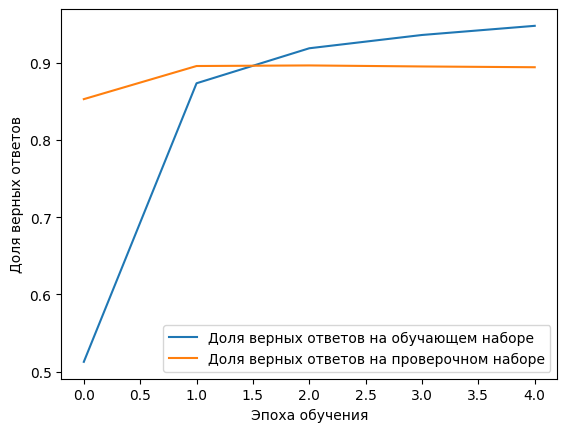

In [ ]:
plt.plot(history_cnn_1.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history_cnn_1.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

In [ ]:
model_cnn_1.evaluate(x_test_1, y_test, verbose=1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2523 - loss: 1.3863


[1.386339783668518, 0.24828948080539703]

### Стоп-слова

In [ ]:
model_cnn_2 = keras.Sequential()
model_cnn_2.add(keras.layers.Embedding(num_words, 32, input_length=new_max_news_len))
model_cnn_2.add(keras.layers.Conv1D(250, 5, padding='valid', activation='relu'))
model_cnn_2.add(keras.layers.Dropout(0.3))
model_cnn_2.add(keras.layers.GlobalMaxPooling1D())
model_cnn_2.add(keras.layers.Dense(128, activation='relu'))
model_cnn_2.add(keras.layers.Dropout(0.5))
model_cnn_2.add(keras.layers.Dense(4, activation='softmax'))

In [ ]:
model_cnn_2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history_cnn_2 = model_cnn.fit(x_train_2,
                            y_train,
                            epochs=5,
                            batch_size=128,
                            validation_split=0.1,
                            callbacks=[checkpoint_callback_cnn_2])

Epoch 1/5
841/844 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4808 - loss: 1.2028
Epoch 1: val_accuracy did not improve from 0.91083
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4816 - loss: 1.2011 - val_accuracy: 0.8683 - val_loss: 0.4059
Epoch 2/5
834/844 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8780 - loss: 0.3833
Epoch 2: val_accuracy did not improve from 0.91083
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8782 - loss: 0.3829 - val_accuracy: 0.9015 - val_loss: 0.2870
Epoch 3/5
830/844 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9270 - loss: 0.2336
Epoch 3: val_accuracy did not improve from 0.91083
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9270 - loss: 0.2337 - val_accuracy: 0.9041 - val_loss: 0.2818
Epoch 4/5
834/844 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9430 - loss: 0.1776
Epoch 4: val_accuracy did not improve from 0.91083
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9430 - loss: 0.1776 - val_accuracy: 0.8995 - val_l

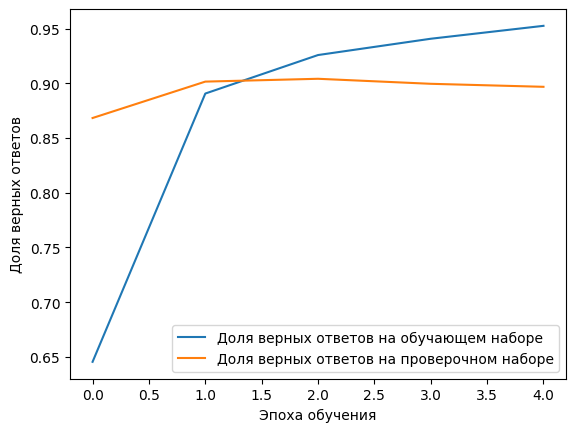

In [ ]:
plt.plot(history_cnn_2.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history_cnn_2.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

In [ ]:
model_cnn_2.evaluate(x_test_2, y_test, verbose=1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2590 - loss: 1.3861


[1.3868780136108398, 0.25]

### Лемматизация

In [ ]:
model_cnn_3 = keras.Sequential()
model_cnn_3.add(keras.layers.Embedding(num_words, 32, input_length=new_max_news_len))
model_cnn_3.add(keras.layers.Conv1D(250, 5, padding='valid', activation='relu'))
model_cnn.add(keras.layers.Dropout(0.3))
model_cnn_3.add(keras.layers.GlobalMaxPooling1D())
model_cnn_3.add(keras.layers.Dense(128, activation='relu'))
model_cnn.add(keras.layers.Dropout(0.5))
model_cnn_3.add(keras.layers.Dense(4, activation='softmax'))

In [ ]:
model_cnn_3.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history_cnn_3 = model_cnn.fit(x_train_3,
                            y_train,
                            epochs=5,
                            batch_size=128,
                            validation_split=0.1,
                            callbacks=[checkpoint_callback_cnn_3])

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8234 - loss: 0.5186
Epoch 1: val_accuracy did not improve from 0.91108
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8235 - loss: 0.5184 - val_accuracy: 0.8948 - val_loss: 0.2916
Epoch 2/5
837/844 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9477 - loss: 0.1551
Epoch 2: val_accuracy did not improve from 0.91108
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9477 - loss: 0.1551 - val_accuracy: 0.8954 - val_loss: 0.3056
Epoch 3/5
842/844 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9637 - loss: 0.1073
Epoch 3: val_accuracy did not improve from 0.91108
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9637 - loss: 0.1073 - val_accuracy: 0.8854 - val_loss: 0.3477
Epoch 4/5
829/844 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9731 - loss: 0.0790
Epoch 4: val_accuracy did not improve from 0.91108
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9730 - loss: 0.0791 - val_accuracy: 0.8872 - val_l

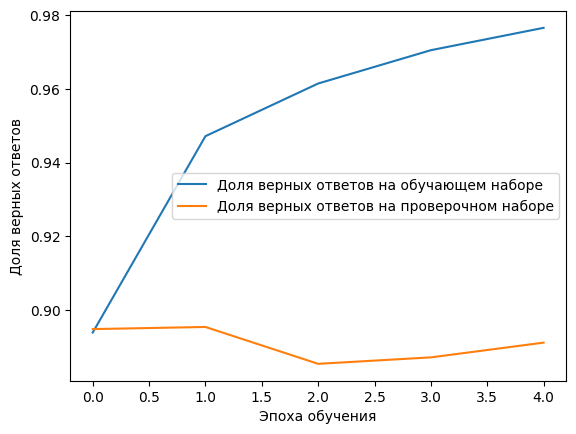

In [ ]:
plt.plot(history_cnn_3.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history_cnn_3.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

In [ ]:
model_cnn_3.evaluate(x_test_3, y_test, verbose=1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2318 - loss: 1.3876


[1.386701226234436, 0.25078946352005005]